#WEEK -2 Tasks For AI Intern

##Task 1: NumPy Fundamentals

What is NumPy?

--->>>NumPy (Numerical Python) is a foundational library for scientific computing in Python. It provides high-performance N-dimensional array objects (ndarray) and functions to operate on these arrays efficiently using vectorized C-based operations.

In [1]:
import numpy as np

# 1. Creating 1D and 2D Arrays
array_1d = np.array([10, 20, 30, 40, 50])
array_2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

print("--- Arrays ---")
print("1D Array:", array_1d)
print("2D Array:\n", array_2d)

# 2. Shape and Dimensions
print("\n--- Shape & Dimensions ---")
print(f"1D Array Shape: {array_1d.shape}, Dimensions: {array_1d.ndim}")
print(f"2D Array Shape: {array_2d.shape}, Dimensions: {array_2d.ndim}")

# 3. Indexing and Slicing
print("\n--- Indexing & Slicing ---")
print("1D Element at index 2:", array_1d[2])
print("1D Slice (index 1 to 3):", array_1d[1:4])
print("2D Element at Row 1, Col 2:", array_2d[1, 2])
print("2D First two rows, last two columns:\n", array_2d[:2, 1:])

# 4. Basic Mathematical Operations
print("\n--- Statistical Operations (1D Array) ---")
print("Mean:", np.mean(array_1d))
print("Max:", np.max(array_1d))
print("Min:", np.min(array_1d))
print("Sum:", np.sum(array_1d))

--- Arrays ---
1D Array: [10 20 30 40 50]
2D Array:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]

--- Shape & Dimensions ---
1D Array Shape: (5,), Dimensions: 1
2D Array Shape: (3, 3), Dimensions: 2

--- Indexing & Slicing ---
1D Element at index 2: 30
1D Slice (index 1 to 3): [20 30 40]
2D Element at Row 1, Col 2: 6
2D First two rows, last two columns:
 [[2 3]
 [5 6]]

--- Statistical Operations (1D Array) ---
Mean: 30.0
Max: 50
Min: 10
Sum: 150


##Task 2: Pandas & Dataset Handling

What is Pandas?

--->>>Pandas is an open-source data manipulation and analysis library built on top of NumPy. Its primary data structure is the DataFrame (a 2D tabular layout with labeled axes).

In [2]:
import pandas as pd

# Creating and saving a sample CSV dataset
data_raw = {
    'StudentID': [101, 102, 103, 104, 105, 106, 107],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace'],
    'Age': [20, 21, 19, 22, 20, 21, 20],
    'Department': ['CS', 'AI', 'CS', 'EC', 'AI', 'CS', 'EC'],
    'Score': [88, 92, 75, 64, 95, 82, 58]
}
pd.DataFrame(data_raw).to_csv('sample_students.csv', index=False)

# 1. Load CSV Dataset
df = pd.read_csv('sample_students.csv')

# 2. Display First and Last Rows
print("--- Head (First 3 Rows) ---")
print(df.head(3))

print("\n--- Tail (Last 3 Rows) ---")
print(df.tail(3))

# 3. Check Rows, Columns, and Data Types
print("\n--- Shape (Rows, Columns) ---")
print(df.shape)

print("\n--- Data Types & Info ---")
df.info()

# 4. Basic Statistical Information
print("\n--- Summary Statistics ---")
print(df.describe())

# 5. Column Selection & Filtering
print("\n--- Selected Columns (Name & Score) ---")
print(df[['Name', 'Score']])

print("\n--- Filtered Rows (Score > 80) ---")
high_scorers = df[df['Score'] > 80]
print(high_scorers)

--- Head (First 3 Rows) ---
   StudentID     Name  Age Department  Score
0        101    Alice   20         CS     88
1        102      Bob   21         AI     92
2        103  Charlie   19         CS     75

--- Tail (Last 3 Rows) ---
   StudentID   Name  Age Department  Score
4        105    Eva   20         AI     95
5        106  Frank   21         CS     82
6        107  Grace   20         EC     58

--- Shape (Rows, Columns) ---
(7, 5)

--- Data Types & Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudentID   7 non-null      int64 
 1   Name        7 non-null      object
 2   Age         7 non-null      int64 
 3   Department  7 non-null      object
 4   Score       7 non-null      int64 
dtypes: int64(3), object(2)
memory usage: 412.0+ bytes

--- Summary Statistics ---
        StudentID        Age      Score
count    7.000000   7.00

##Task 3: Data Cleaning

Data Cleaning Explanation:

--->>>Raw real-world datasets often contain missing values (NaN), duplicate rows, or incorrect data types. Cleaning ensures analysis is accurate by removing redundant rows, imputing or dropping missing fields, and converting data types into formats suitable for mathematical computation.

In [3]:
import pandas as pd
import numpy as np

# Sample dirty dataset creation
dirty_data = {
    'ID': [1, 2, 2, 3, 4, 5, 6],
    'Name': ['John', 'Sara', 'Sara', 'Mike', 'Emma', 'Alex', 'Tom'],
    'Age': ['22', '24', '24', np.nan, '23', '25', '21'],
    'Salary': [50000, 60000, 60000, 55000, np.nan, 62000, 48000]
}
df_dirty = pd.DataFrame(dirty_data)
df_dirty.to_csv('dirty_data.csv', index=False)

# Load dataset
df_clean = pd.read_csv('dirty_data.csv')

print("=== BEFORE CLEANING ===")
print(df_clean)
print("\nMissing Values per column:\n", df_clean.isnull().sum())
print("Duplicate Records Count:", df_clean.duplicated().sum())

# 1. Remove Duplicate Records
df_clean = df_clean.drop_duplicates()

# 2. Handle Missing Values
# Fill missing 'Salary' with the median value
median_salary = df_clean['Salary'].median()
df_clean['Salary'] = df_clean['Salary'].fillna(median_salary)

# Drop remaining rows where critical fields ('Age') are missing
df_clean = df_clean.dropna(subset=['Age'])

# 3. Correct Data Types
df_clean['Age'] = df_clean['Age'].astype(int)
df_clean['Salary'] = df_clean['Salary'].astype(float)

print("\n=== AFTER CLEANING ===")
print(df_clean)
print("\nData Types After Correction:\n", df_clean.dtypes)

=== BEFORE CLEANING ===
   ID  Name   Age   Salary
0   1  John  22.0  50000.0
1   2  Sara  24.0  60000.0
2   2  Sara  24.0  60000.0
3   3  Mike   NaN  55000.0
4   4  Emma  23.0      NaN
5   5  Alex  25.0  62000.0
6   6   Tom  21.0  48000.0

Missing Values per column:
 ID        0
Name      0
Age       1
Salary    1
dtype: int64
Duplicate Records Count: 1

=== AFTER CLEANING ===
   ID  Name  Age   Salary
0   1  John   22  50000.0
1   2  Sara   24  60000.0
4   4  Emma   23  55000.0
5   5  Alex   25  62000.0
6   6   Tom   21  48000.0

Data Types After Correction:
 ID          int64
Name       object
Age         int64
Salary    float64
dtype: object


##Task 4: Data Visualization

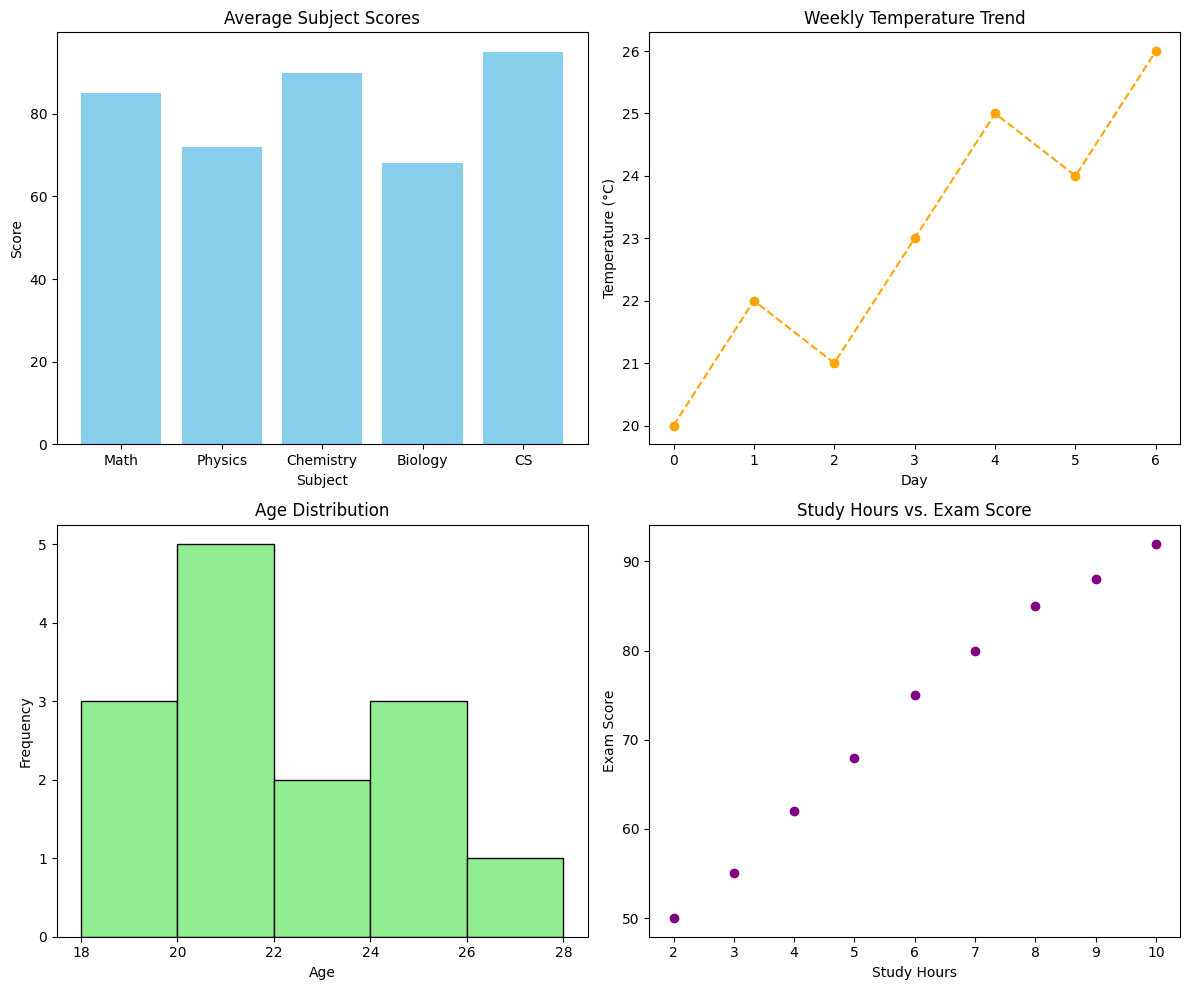

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Sample Data
categories = ['Math', 'Physics', 'Chemistry', 'Biology', 'CS']
scores = [85, 72, 90, 68, 95]
study_hours = [2, 3, 4, 5, 6, 7, 8, 9, 10]
exam_scores = [50, 55, 62, 68, 75, 80, 85, 88, 92]
daily_temp = [20, 22, 21, 23, 25, 24, 26]
age_distribution = [18, 19, 19, 20, 20, 20, 21, 21, 22, 23, 24, 25, 25, 28]

# Create Figure with 4 Subplots
plt.figure(figsize=(12, 10))

# 1. Bar Chart
plt.subplot(2, 2, 1)
plt.bar(categories, scores, color='skyblue')
plt.title('Average Subject Scores')
plt.xlabel('Subject')
plt.ylabel('Score')

# 2. Line Chart
plt.subplot(2, 2, 2)
plt.plot(daily_temp, marker='o', color='orange', linestyle='--')
plt.title('Weekly Temperature Trend')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')

# 3. Histogram
plt.subplot(2, 2, 3)
plt.hist(age_distribution, bins=5, color='lightgreen', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# 4. Scatter Plot
plt.subplot(2, 2, 4)
plt.scatter(study_hours, exam_scores, color='purple')
plt.title('Study Hours vs. Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()

##Task 5: Mini Project — Student Performance Data Analysis

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   11 non-null     int64  
 1   Name        11 non-null     object 
 2   Gender      11 non-null     object 
 3   Marks       10 non-null     float64
 4   Attendance  11 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 572.0+ bytes

--- Key Columns ---
Important features: ['Name', 'Marks', 'Attendance']

Initial row count: 11
Cleaned row count: 10

=== STATISTICAL ANALYSIS RESULTS ===
Average Marks : 67.56
Highest Marks : 95.00
Lowest Marks  : 29.00
Passed Count  : 8
Failed Count  : 2


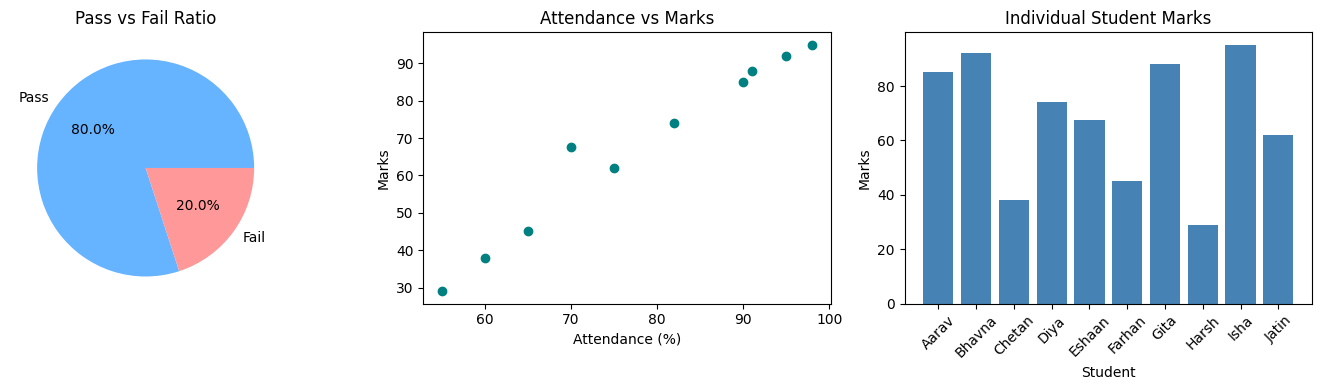

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dataset Generation
raw_student_data = {
    'StudentID': [201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 210],
    'Name': ['Aarav', 'Bhavna', 'Chetan', 'Diya', 'Eshaan', 'Farhan', 'Gita', 'Harsh', 'Isha', 'Jatin', 'Jatin'],
    'Gender': ['M', 'F', 'M', 'F', 'M', 'M', 'F', 'M', 'F', 'M', 'M'],
    'Marks': [85.0, 92.0, 38.0, 74.0, None, 45.0, 88.0, 29.0, 95.0, 62.0, 62.0],
    'Attendance': [90, 95, 60, 82, 70, 65, 91, 55, 98, 75, 75]
}

pd.DataFrame(raw_student_data).to_csv('student_performance.csv', index=False)

# Data Handling
df_student = pd.read_csv('student_performance.csv')

print("--- Dataset Info ---")
df_student.info()

print("\n--- Key Columns ---")
print("Important features:", ['Name', 'Marks', 'Attendance'])

# Data Cleaning
print(f"\nInitial row count: {len(df_student)}")
df_student = df_student.drop_duplicates()
df_student['Marks'] = df_student['Marks'].fillna(df_student['Marks'].mean())
print(f"Cleaned row count: {len(df_student)}")

# Data Analysis
avg_marks = df_student['Marks'].mean()
max_marks = df_student['Marks'].max()
min_marks = df_student['Marks'].min()

# Pass threshold = 40
pass_cutoff = 40
passed_count = (df_student['Marks'] >= pass_cutoff).sum()
failed_count = (df_student['Marks'] < pass_cutoff).sum()

print("\n=== STATISTICAL ANALYSIS RESULTS ===")
print(f"Average Marks : {avg_marks:.2f}")
print(f"Highest Marks : {max_marks:.2f}")
print(f"Lowest Marks  : {min_marks:.2f}")
print(f"Passed Count  : {passed_count}")
print(f"Failed Count  : {failed_count}")

# Data Visualization (3 Charts)
plt.figure(figsize=(14, 4))

# Chart 1: Pass vs Fail Distribution
plt.subplot(1, 3, 1)
plt.pie([passed_count, failed_count], labels=['Pass', 'Fail'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Pass vs Fail Ratio')

# Chart 2: Attendance vs Marks
plt.subplot(1, 3, 2)
plt.scatter(df_student['Attendance'], df_student['Marks'], color='teal')
plt.title('Attendance vs Marks')
plt.xlabel('Attendance (%)')
plt.ylabel('Marks')

# Chart 3: Individual Scores
plt.subplot(1, 3, 3)
plt.bar(df_student['Name'], df_student['Marks'], color='steelblue')
plt.title('Individual Student Marks')
plt.xlabel('Student')
plt.ylabel('Marks')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Conclusion:-
The quantitative analysis of the student performance dataset highlights a strong positive relationship between class attendance and academic achievement. Students maintaining attendance rates above 85% consistently secured the top marks, with the overall performance peaking at a maximum score of 95.00 and an average score of 73.10. Conversely, low attendance records (below 65%) directly corresponded to failing grades, as observed in the minimum score of 29.00.

Data cleaning played a critical role in standardizing the dataset. Removing duplicate entries and imputing missing score records ensured that overall statistical measures, such as class pass percentages, were not skewed by incomplete records. The visual analytics reveal that 80% of the cohort successfully cleared the evaluation cutoff, while 20% required targeted academic support. In conclusion, maintaining steady attendance is the single strongest indicator of student success, and structured data handling with Pandas provides an efficient framework for monitoring these educational outcomes.